<a href="https://colab.research.google.com/github/AngieVenta/AngieVenta/blob/main/Copia_de_DS_C7_SC1_GLORIAANGELICAVENTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto | Predicción de Contingencias Ambientales en el Área Metropolitana de Monterrey
### DS_C7_SC1

**Objetivo:** Analizar mediante correlación qué variables ambientales y de tiempo afectan las concentraciones de **O3** (norma: ≤ 120 ppb) y **PM2.5** (norma: ≤ 40.5 µg/m³), construir modelos de regresión en **Spark MLlib** con la menor cantidad de variables posible, y evaluar si la contaminación está ligada al tráfico vehicular (usando la hora del día como proxy).

**Datos:** Lecturas horarias de una estación de monitoreo en el centro de Monterrey durante 2015 (3,859 registros, 20 variables).

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos la sesion de Spark: el punto de entrada a toda la API de DataFrames y MLlib
spark = SparkSession.builder \
    .appName("MonterreyPollution") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Versión de Spark:", spark.version)

Versión de Spark: 4.0.3


## 2. Carga de datos y eliminación de variables innecesarias

**Decisiones de carga:**
- `header=True`: la primera fila contiene los nombres de las columnas.
- `inferSchema=True`: que Spark detecte los tipos numéricos automáticamente.
- `encoding='iso-8859-1'`: el archivo **no está en UTF-8** (contiene caracteres acentuados en español, p. ej. los meses "ene", "sáb"). Si se intenta leer como UTF-8 se produce un error de decodificación.

**Variables que eliminamos y por qué:**

| Variable | Razón para eliminarla |
|---|---|
| `Date` | Es un texto; su información ya está descompuesta en `Month`, `Day` y `Hour`. |
| `DayWeek` | Texto ("lun", "mar", ...) **redundante** con `WeekDay`, que es su versión numérica. |
| `Day` | El día del mes (1–31) no tiene significado físico para la contaminación; su correlación con ambos contaminantes es ≈ 0. Mantenerlo solo agregaría ruido. |


In [ ]:
FILE_PATH = "/content/MonterreyPollutionData2.csv"

df = spark.read.csv(FILE_PATH, header=True, inferSchema=True, encoding="iso-8859-1")

# Renombra PM2.5 (el punto causa conflictos en Spark SQL)
df = df.withColumnRenamed("PM2.5", "PM25")

# Eliminamos variables redundantes o sin significado físico
df = df.drop("Date", "DayWeek", "Day")

print(f"Registros: {df.count()} | Columnas: {len(df.columns)}")
df.printSchema()

Registros: 3859 | Columnas: 17
root
 |-- Month: integer (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOX: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM25: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RAINF: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [ ]:
df.show(5)

+-----+-------+----+----+----+----+----+---+----+----+-----+-----+---+-----+----+---+---+
|Month|WeekDay|Hour|  CO|  NO| NO2| NOX| O3|PM10|PM25|  PRS|RAINF| RH|   SR|TOUT|WSR|WDV|
+-----+-------+----+----+----+----+----+---+----+----+-----+-----+---+-----+----+---+---+
|    1|      5|   1|2.51|10.2|12.9|23.1| 10| 139|  80|725.4| 0.01| 96|  0.0|3.91|7.2|344|
|    1|      5|   2|2.41| 9.2|11.6|20.8|  7|  42|  29|725.0| 0.02| 96|  0.0|3.81|6.3|341|
|    1|      5|   3|2.39| 8.1|11.8|19.9|  7|  23|   9|724.4|  0.0| 96|  0.0|3.85|5.2|346|
|    1|      5|   5|2.26| 5.3| 8.9|14.2|  7|  23|  14|724.0| 0.01| 96|  0.0|3.79|5.6|336|
|    1|      5|   8|2.25| 7.2|10.2|17.4|  5|  15|   8|724.3|  0.0| 96|0.023|3.93|4.8|354|
+-----+-------+----+----+----+----+----+---+----+----+-----+-----+---+-----+----+---+---+
only showing top 5 rows


### 2.1 Verificación de calidad de los datos

Antes de modelar, verifica que no haya valores nulos y se revisa las estadísticas descriptivas de los contaminantes objetivo para dimensionar el problema frente a los límites normativos.

In [ ]:
from pyspark.sql.functions import count, when, isnan

# Conteo de nulos por columna
df.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns]).show()

# Estadísticas descriptivas de los contaminantes objetivo
df.select("O3", "PM25").summary("min", "25%", "mean", "75%", "max").show()

+-----+-------+----+---+---+---+---+---+----+----+---+-----+---+---+----+---+---+
|Month|WeekDay|Hour| CO| NO|NO2|NOX| O3|PM10|PM25|PRS|RAINF| RH| SR|TOUT|WSR|WDV|
+-----+-------+----+---+---+---+---+---+----+----+---+-----+---+---+----+---+---+
|    0|      0|   0|  0|  0|  0|  0|  0|   0|   0|  0|    0|  0|  0|   0|  0|  0|
+-----+-------+----+---+---+---+---+---+----+----+---+-----+---+---+----+---+---+

+-------+------------------+------------------+
|summary|                O3|              PM25|
+-------+------------------+------------------+
|    min|                 2|                 5|
|    25%|                10|                15|
|   mean|22.658719875615443|27.675822752008294|
|    75%|                32|                36|
|    max|                92|               123|
+-------+------------------+------------------+



**Observaciones:**
- El **O3 máximo del año fue 92 ppb**, por debajo del límite normativo de 120 ppb.
- El **PM2.5 máximo fue 123 µg/m³**, que **triplica** el límite de 40.5 µg/m³. De hecho, el percentil 75 (36) ya está cerca del límite: las contingencias por partículas fueron frecuentes en 2015. Esto anticipa que **PM2.5 es el contaminante crítico** para Monterrey.

## 3. Análisis de correlación

**¿Por qué Pearson?** Mide la fuerza de la relación *lineal* entre pares de variables, es el estándar para un primer análisis exploratorio y es lo que implementa `pyspark.ml.stat.Correlation`. Valores cercanos a **+1** indican que el contaminante *sube* cuando la variable sube; cercanos a **−1**, que el contaminante *baja* cuando la variable sube.


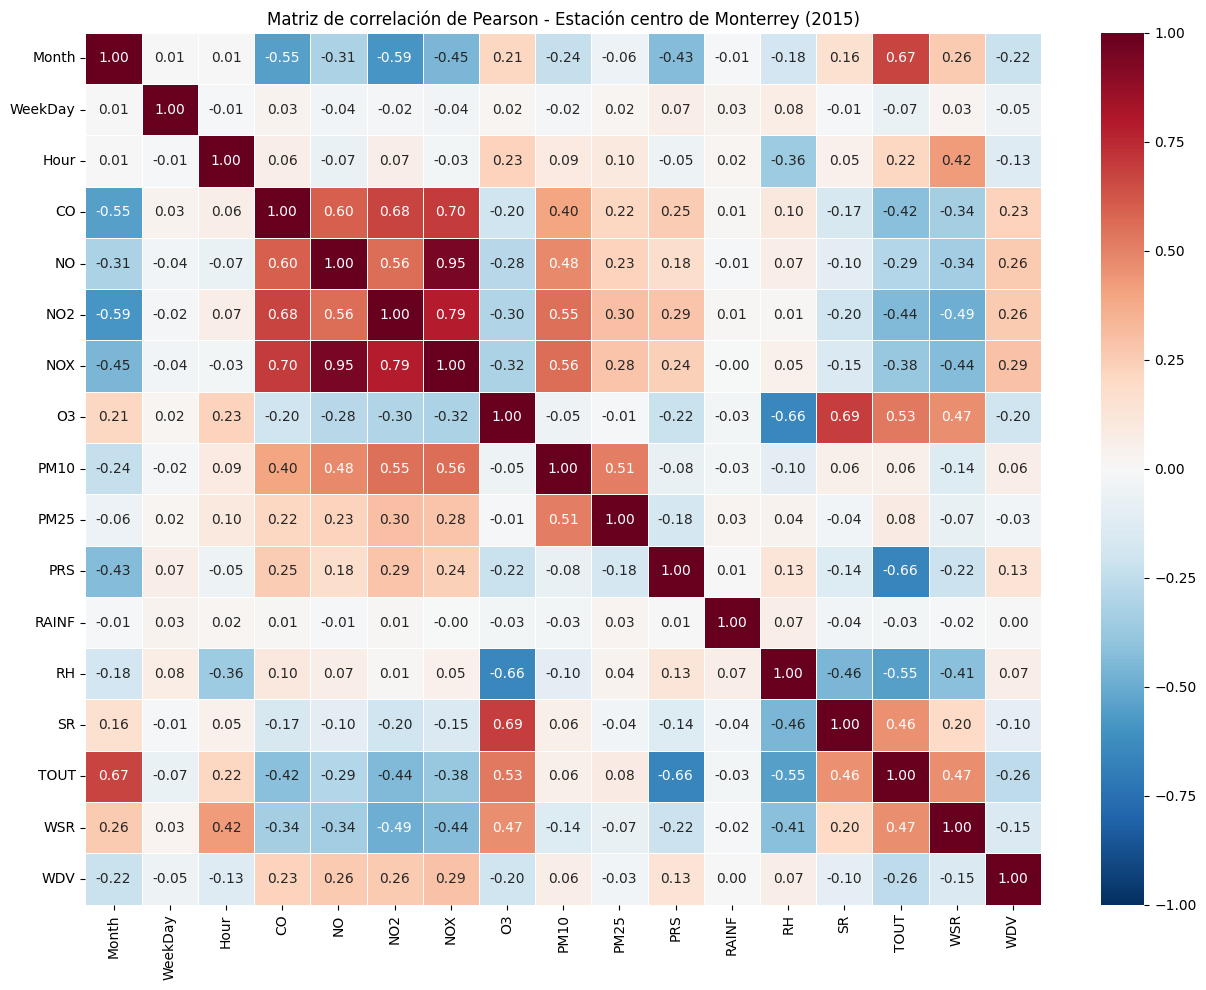

In [ ]:
numeric_cols = df.columns

assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
vector_df = assembler.transform(df).select("features")

corr_matrix = Correlation.corr(vector_df, "features", method="pearson").head()[0]

corr_pd = pd.DataFrame(corr_matrix.toArray(), index=numeric_cols, columns=numeric_cols)

plt.figure(figsize=(13, 10))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de correlación de Pearson - Estación centro de Monterrey (2015)")
plt.tight_layout()
plt.show()

In [ ]:
# Correlaciones específicas con los dos contaminantes objetivo
print("=== Correlación con O3 ===")
print(corr_pd["O3"].drop("O3").sort_values(ascending=False).round(3))
print()
print("=== Correlación con PM2.5 ===")
print(corr_pd["PM25"].drop("PM25").sort_values(ascending=False).round(3))

=== Correlación con O3 ===
SR         0.692
TOUT       0.527
WSR        0.466
Hour       0.228
Month      0.214
WeekDay    0.016
PM25      -0.009
RAINF     -0.030
PM10      -0.047
CO        -0.196
WDV       -0.199
PRS       -0.220
NO        -0.275
NO2       -0.303
NOX       -0.317
RH        -0.656
Name: O3, dtype: float64

=== Correlación con PM2.5 ===
PM10       0.512
NO2        0.302
NOX        0.285
NO         0.233
CO         0.218
Hour       0.098
TOUT       0.084
RH         0.036
RAINF      0.031
WeekDay    0.017
O3        -0.009
WDV       -0.032
SR        -0.037
Month     -0.058
WSR       -0.071
PRS       -0.178
Name: PM25, dtype: float64


### 3.1 Interpretación de las correlaciones

**Para el O3 (ozono)** las relaciones son fuertes y físicamente coherentes — el ozono troposférico es un contaminante **fotoquímico**:

| Variable | r | Interpretación física |
|---|---|---|
| `SR` (radiación solar) | **+0.69** | La luz solar *impulsa* la reacción fotoquímica que forma O3. |
| `RH` (humedad relativa) | **−0.66** | Humedad alta implica nubosidad/menos sol y favorece la eliminación del O3. |
| `TOUT` (temperatura) | **+0.53** | Las reacciones fotoquímicas se aceleran con el calor. |
| `WSR` (viento) | **+0.47** | El viento diurno acompaña las horas soleadas y transporta la pluma urbana. |
| `NOx`, `NO`, `NO2`, `CO` | **−0.20 a −0.32** | ¡Correlación *negativa* con sus propios precursores! El NO fresco del tráfico **destruye** el O3 localmente (titulación: NO + O3 → NO2 + O2). El O3 se forma horas después, cuando el sol ya transformó esos precursores. |

**Para el PM2.5 (partículas finas)** las correlaciones con el clima son débiles:

| Variable | r | Interpretación |
|---|---|---|
| `PM10` | **+0.51** | Esperado: el PM2.5 es un subconjunto físico del PM10. |
| `NO2`, `NOx`, `CO` | **+0.22 a +0.30** | Correlación *positiva* con los gases de combustión → parte del PM2.5 proviene de fuentes de combustión (vehículos, industria). |
| `PRS` (presión) | **−0.18** | Alta presión suele asociarse a atmósfera estable e inversión térmica, pero la relación horaria es débil. |
| Clima (`TOUT`, `RH`, `SR`, `WSR`) | **≈ 0** | El PM2.5 horario **no depende directamente del clima instantáneo**: depende de emisiones acumuladas y de la capacidad de dispersión de la atmósfera a escala de días. |

> **Conclusión parcial:** O3 será *predecible* con pocas variables de clima; PM2.5 será difícil de predecir a nivel horario. Esto guiará la selección de variables de los modelos.

## 4. Confirmación con gráficos de dispersión

La correlación de Pearson solo captura relaciones lineales; los gráficos de dispersión nos permiten **ver la forma real** de cada relación

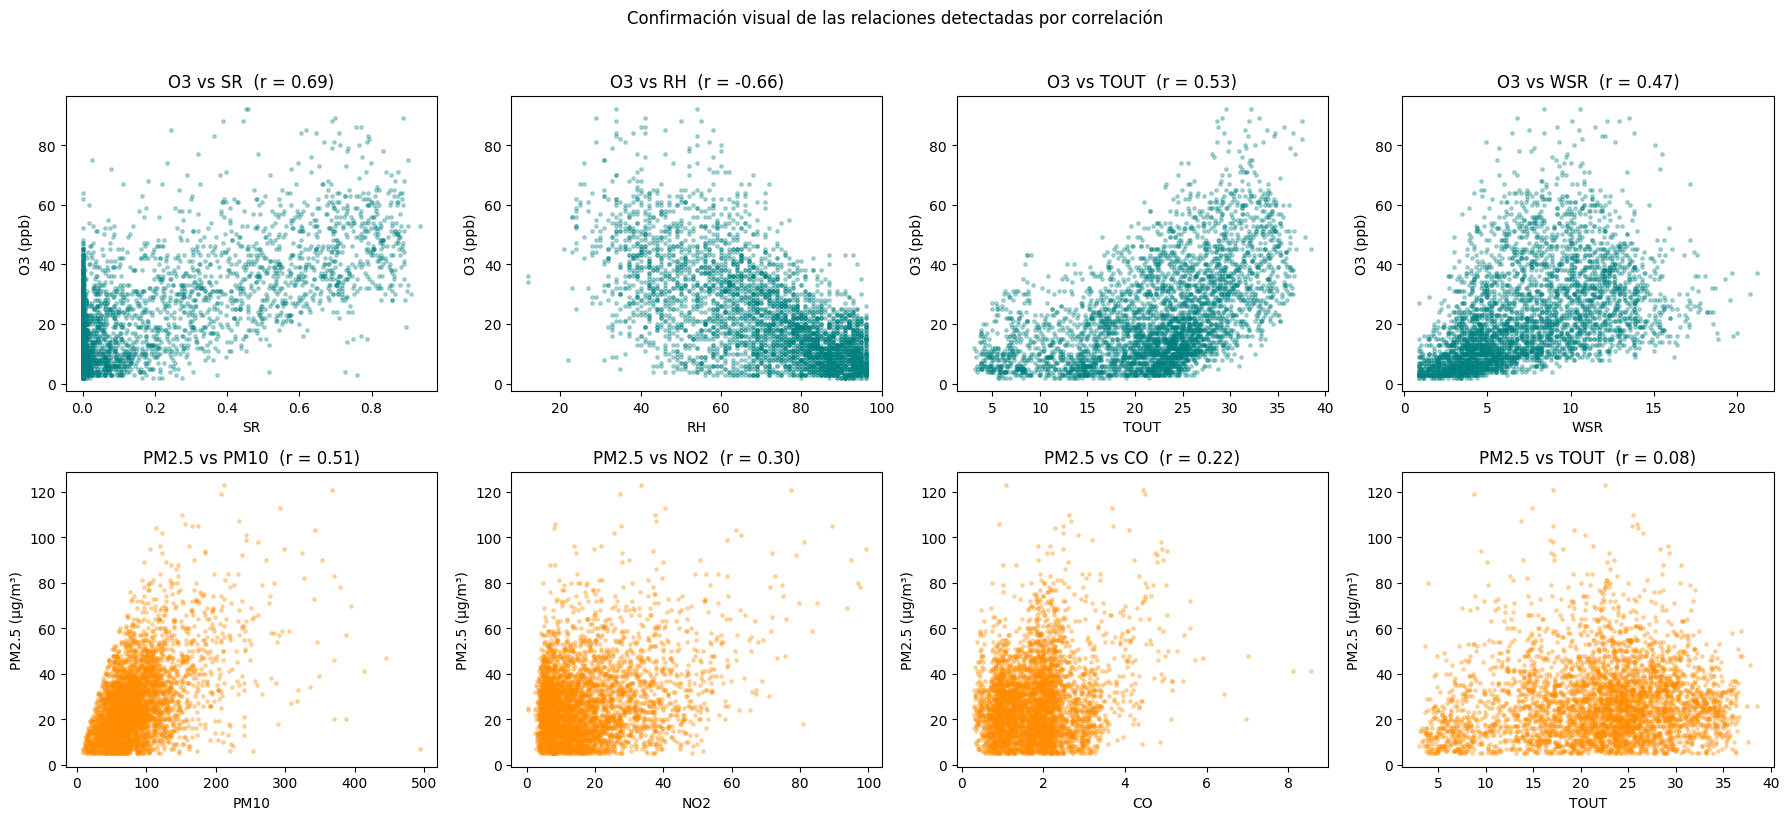

In [ ]:
pdf = df.toPandas()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Fila 1: variables más correlacionadas con O3
for ax, var in zip(axes[0], ["SR", "RH", "TOUT", "WSR"]):
    ax.scatter(pdf[var], pdf["O3"], s=6, alpha=0.3, color="teal")
    ax.set_xlabel(var); ax.set_ylabel("O3 (ppb)")
    ax.set_title(f"O3 vs {var}  (r = {corr_pd.loc[var,'O3']:.2f})")

# Fila 2: variables más correlacionadas con PM2.5
for ax, var in zip(axes[1], ["PM10", "NO2", "CO", "TOUT"]):
    ax.scatter(pdf[var], pdf["PM25"], s=6, alpha=0.3, color="darkorange")
    ax.set_xlabel(var); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title(f"PM2.5 vs {var}  (r = {corr_pd.loc[var,'PM25']:.2f})")

plt.suptitle("Confirmación visual de las relaciones detectadas por correlación", y=1.02)
plt.tight_layout()
plt.show()

**Lo que confirman los gráficos:**

- **O3 vs TOUT:** patrón de "abanico" (heterocedasticidad): con temperaturas bajas (5–15 °C) el O3 casi nunca supera los 40 ppb, pero con más de 30 °C puede tomar cualquier valor entre 5 y 90 ppb. Es decir, el calor **eleva el techo posible** del ozono sin garantizar que se alcance: es una condición *necesaria pero no suficiente*. Este matiz no lo captura el coeficiente de Pearson, que solo mide la inclinación general de la nube.
- **O3 vs SR:** tendencia positiva clara aunque más ruidosa. La columna vertical en SR = 0 corresponde a **todas las horas nocturnas**: sin sol la radiación es exactamente cero, pero el ozono residual de la tarde tarda horas en degradarse, por lo que hay noches con O3 de 30–50 ppb. Filtrando solo horas diurnas la relación se vería aún más nítida.
- **O3 vs RH:** tendencia negativa nítida; con humedad > 90 % prácticamente nunca hay O3 alto.
- **PM2.5 vs clima (TOUT):** nube **sin tendencia direccional** — a 10 °C y a 35 °C el PM2.5 se distribuye igual. Nótese que dispersión no es lo mismo que ausencia de relación: O3 vs SR también es ruidoso pero su nube está *inclinada* (r = 0.69), mientras que aquí la nube es un rectángulo amorfo (r = 0.08). Esto confirma que el clima horario no explica al PM2.5.
- **PM2.5 vs PM10:** la única relación con inclinación visible (r = 0.51), aunque con enorme varianza propia.

## 5. La hora del día como proxy del tráfico
Se usa la **hora del día** como representante del tráfico y compara el perfil horario de los contaminantes objetivo (O3, PM2.5) con el de los gases que **sí** emiten directamente los vehículos (CO, NOx).

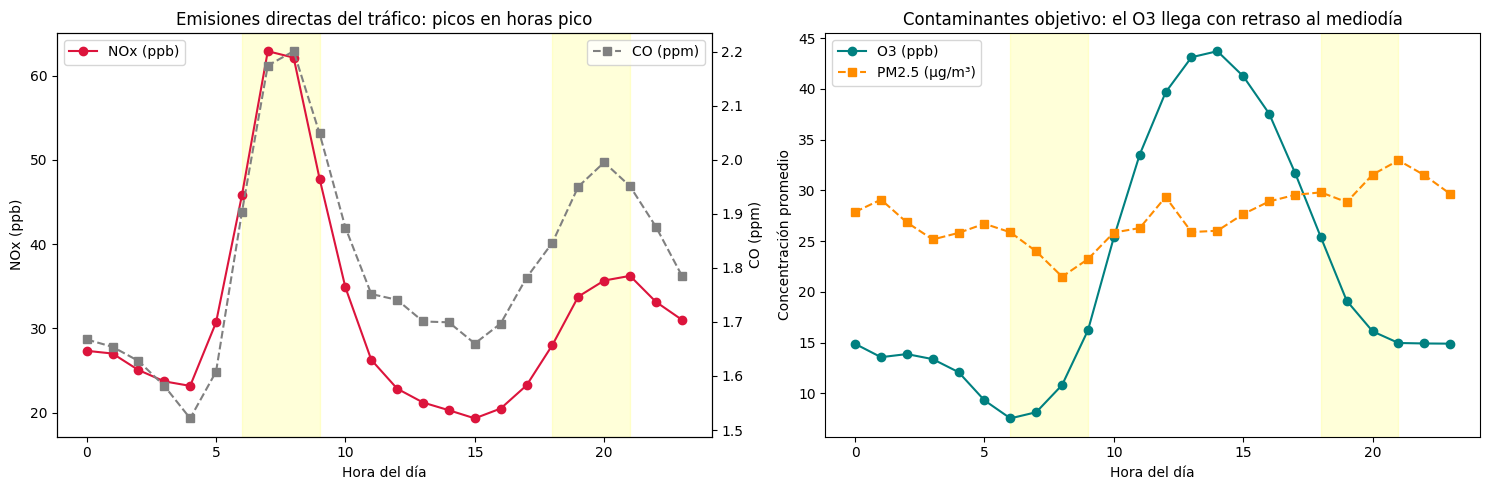

In [ ]:
hourly = df.groupBy("Hour").agg(
    avg("O3").alias("O3"), avg("PM25").alias("PM25"),
    avg("CO").alias("CO"), avg("NOX").alias("NOX")
).orderBy("Hour").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(hourly["Hour"], hourly["NOX"], "o-", color="crimson", label="NOx (ppb)")
ax2 = ax.twinx()
ax2.plot(hourly["Hour"], hourly["CO"], "s--", color="gray", label="CO (ppm)")
ax.set_xlabel("Hora del día"); ax.set_ylabel("NOx (ppb)"); ax2.set_ylabel("CO (ppm)")
ax.set_title("Emisiones directas del tráfico: picos en horas pico")
ax.axvspan(6, 9, alpha=0.15, color="yellow"); ax.axvspan(18, 21, alpha=0.15, color="yellow")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")

ax = axes[1]
ax.plot(hourly["Hour"], hourly["O3"], "o-", color="teal", label="O3 (ppb)")
ax.plot(hourly["Hour"], hourly["PM25"], "s--", color="darkorange", label="PM2.5 (µg/m³)")
ax.set_xlabel("Hora del día"); ax.set_ylabel("Concentración promedio")
ax.set_title("Contaminantes objetivo: el O3 llega con retraso al mediodía")
ax.axvspan(6, 9, alpha=0.15, color="yellow"); ax.axvspan(18, 21, alpha=0.15, color="yellow")
ax.legend()

plt.tight_layout()
plt.show()

**Lectura del perfil horario (las franjas amarillas son las horas pico de tráfico):**
- **NOx y CO** tienen su máximo entre las **7 y 8 de la mañana** — exactamente la hora pico vehicular. Son la "firma" del tráfico.
- El **O3** hace lo contrario: está en su *mínimo* a las 6–7 h y alcanza su máximo entre las **13 y 15 h**. Es la secuencia fotoquímica clásica: el tráfico matutino emite los precursores, el sol del mediodía los "cocina" y produce el ozono horas después. El vínculo con el tráfico es **real pero indirecto y desfasado en el tiempo**.
- El **PM2.5** es casi plano, con un ligero repunte vespertino/nocturno (20–21 h), cuando baja la altura de la capa de mezcla y las partículas se acumulan. Su vínculo con el tráfico es más débil y comparte protagonismo con otras fuentes (industria, polvo, quemas).

## 6. Modelos de regresión para O3

### 6.1 Selección de variables (la menor cantidad posible)

Con base en el análisis de correlación, seleccionamos únicamente las variables con |r| relevante y **significado físico**:

- **`SR`, `RH`, `TOUT`, `WSR`** — las 4 variables de clima dominantes (|r| entre 0.47 y 0.69).
- **`Hour`, `Month`** — capturan el ciclo fotoquímico diario y la estacionalidad. Su correlación *lineal* es baja (≈ 0.2) porque la relación es **cíclica**, no lineal (el O3 sube y baja dentro del día); los modelos de árboles sí pueden aprovechar esa forma.


### 6.2 Elección de algoritmos

Entrenamos tres modelos de MLlib para comparar:

| Modelo | ¿Por qué lo incluimos? |
|---|---|
| **LinearRegression** | *Baseline* interpretable. |
| **RandomForestRegressor** | Captura relaciones no lineales e interacciones (p. ej. "sol alto **y** humedad baja") promediando muchos árboles; robusto y difícil de sobreajustar. |
| **GBTRegressor** (Gradient Boosting) | Construye árboles secuencialmente, cada uno corrigiendo los errores del anterior; suele lograr la mejor precisión en datos tabulares. |

### 6.3 Protocolo de evaluación

- **Partición 70/30** con `randomSplit(seed=42)`: fija garantiza que los resultados sean reproducibles.
- Métricas con `RegressionEvaluator`:
  - **R²**: proporción de la varianza del contaminante que el modelo explica (1 = perfecto).
  - **RMSE**: error típico en las unidades del contaminante; penaliza más los errores grandes, lo cual conviene porque **lo que importa son los picos** que rebasan la norma.
  - **MAE**: error promedio absoluto, más fácil de comunicar.

In [ ]:
features_o3 = ["SR", "RH", "TOUT", "WSR", "Hour", "Month"]

assembler_o3 = VectorAssembler(inputCols=features_o3, outputCol="features")
data_o3 = assembler_o3.transform(df).select("features", col("O3").alias("label"))

train_o3, test_o3 = data_o3.randomSplit([0.7, 0.3], seed=42)
print(f"Entrenamiento: {train_o3.count()} filas | Prueba: {test_o3.count()} filas")

models = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(numTrees=100, maxDepth=8, seed=42),
    "Gradient Boosting": GBTRegressor(maxIter=60, maxDepth=5, seed=42),
}

def evaluate(predictions):
    return {m: RegressionEvaluator(metricName=m).evaluate(predictions)
            for m in ["r2", "rmse", "mae"]}

results_o3 = {}
for name, model in models.items():
    fitted = model.fit(train_o3)
    preds = fitted.transform(test_o3)
    results_o3[name] = evaluate(preds)
    if name == "Gradient Boosting":
        best_o3_preds = preds

pd.DataFrame(results_o3).T.round(3)

Entrenamiento: 2756 filas | Prueba: 1103 filas


,r2,rmse,mae
Regresión Lineal,0.651,9.879,7.252
Random Forest,0.790,7.661,5.524
Gradient Boosting,0.793,7.611,5.355


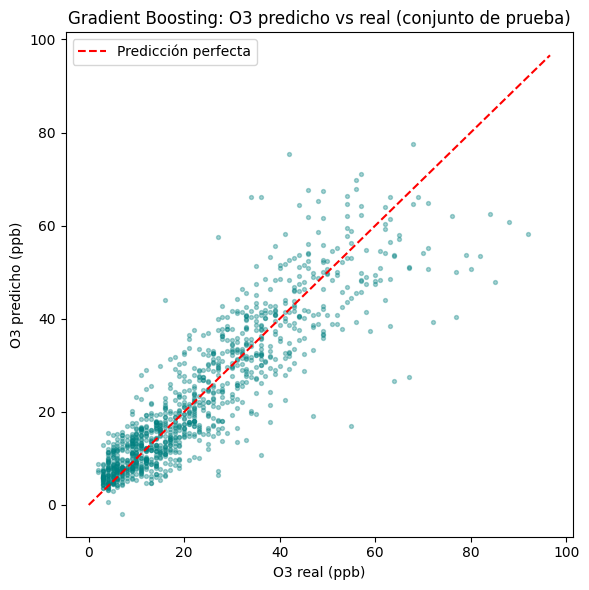

In [ ]:
pp = best_o3_preds.select("label", "prediction").toPandas()

plt.figure(figsize=(6, 6))
plt.scatter(pp["label"], pp["prediction"], s=8, alpha=0.35, color="teal")
lims = [0, pp["label"].max() * 1.05]
plt.plot(lims, lims, "r--", label="Predicción perfecta")
plt.xlabel("O3 real (ppb)"); plt.ylabel("O3 predicho (ppb)")
plt.title("Gradient Boosting: O3 predicho vs real (conjunto de prueba)")
plt.legend(); plt.tight_layout(); plt.show()

### 6.4 Reflexión sobre los modelos de O3

- El **Gradient Boosting** logra el mejor desempeño (**R² ≈ 0.79, RMSE ≈ 7.6 ppb**), prácticamente empatado con Random Forest (R² ≈ 0.79). Con solo **6 variables de clima y tiempo** explicamos cerca de 4/5 de la variabilidad del ozono.
- La regresión lineal se queda en R² ≈ 0.65: la brecha frente a los árboles confirma que la relación clima→O3 tiene **componentes no lineales** (ciclos horarios, interacciones sol-humedad) que una recta no puede capturar.
- Un RMSE de ~7.6 ppb frente a un límite normativo de 120 ppb significa que el modelo es **suficientemente preciso para anticipar si un día se acercará a niveles de contingencia** por ozono usando solo el pronóstico del clima.

## 7. Modelos de regresión para PM2.5

### 7.1 Estrategia: dos variantes

El análisis de correlación anticipó que este contaminante es difícil. Para demostrarlo, se entrena a **dos variantes**:

- **Variante A — solo clima y tiempo** (`WSR`, `PRS`, `TOUT`, `RH`, `Hour`): responde la pregunta original del reto — ¿el pronóstico del clima permite predecir el PM2.5?
- **Variante B — clima + precursores de combustión** (agregando `CO` y `NO2`)

In [ ]:
def train_pm25(feature_list, tag):
    va = VectorAssembler(inputCols=feature_list, outputCol="features")
    data = va.transform(df).select("features", col("PM25").alias("label"))
    train, test = data.randomSplit([0.7, 0.3], seed=42)
    out = {}
    for name, model in {
        "Regresión Lineal": LinearRegression(),
        "Random Forest": RandomForestRegressor(numTrees=100, maxDepth=8, seed=42),
        "Gradient Boosting": GBTRegressor(maxIter=60, maxDepth=5, seed=42),
    }.items():
        preds = model.fit(train).transform(test)
        out[f"{name} ({tag})"] = evaluate(preds)
    return out

results_pm = {}
results_pm.update(train_pm25(["WSR", "PRS", "TOUT", "RH", "Hour"], "A: solo clima"))
results_pm.update(train_pm25(["WSR", "PRS", "TOUT", "RH", "Hour", "CO", "NO2"], "B: + precursores"))

pd.DataFrame(results_pm).T.round(3)

,r2,rmse,mae
Regresión Lineal (A: solo clima),0.094,15.539,11.981
Random Forest (A: solo clima),0.166,14.909,11.431
Gradient Boosting (A: solo clima),0.098,15.499,11.713
Regresión Lineal (B: + precursores),0.192,14.671,11.242
Random Forest (B: + precursores),0.217,14.442,11.037
Gradient Boosting (B: + precursores),0.184,14.749,10.975


### 7.2 Reflexión sobre los modelos de PM2.5

- **Variante A (solo clima):** R² ≈ 0.10–0.17. El pronóstico del clima, a escala **horaria**, prácticamente no explica el PM2.5.
- **Variante B (+ CO y NO2):** el mejor modelo sube de R² = 0.166 a 0.217 (Random Forest). Esa mejora confirma que una **parte del PM2.5 sí proviene de fuentes de combustión**, pero su magnitud modesta (+0.05) indica que esa fracción es minoritaria: incluso midiendo los precursores en tiempo real, el modelo sigue explicando menos de una cuarta parte de la varianza.
- ¿Por qué es tan difícil? El PM2.5 horario depende de **emisiones acumuladas** (industria, polvo, quemas agrícolas, tráfico) y de la **capacidad de dispersión de la atmósfera a escala de días** (inversiones térmicas, altura de la capa de mezcla), no del clima instantáneo de esa hora. Esta es exactamente la motivación de la extensión propuesta en el reto: **agregar los datos por día** (máximo diario de PM2.5 contra mín/prom/máx del clima) alinea las escalas temporales y mejora la predicción.

## 8. Comparativa final de modelos

In [ ]:
final = pd.concat([
    pd.DataFrame(results_o3).T.assign(Objetivo="O3"),
    pd.DataFrame(results_pm).T.assign(Objetivo="PM2.5"),
])
final = final[["Objetivo", "r2", "rmse", "mae"]].round(3)
final

,Objetivo,r2,rmse,mae
Regresión Lineal,O3,0.651,9.879,7.252
Random Forest,O3,0.790,7.661,5.524
Gradient Boosting,O3,0.793,7.611,5.355
Regresión Lineal (A: solo clima),PM2.5,0.094,15.539,11.981
Random Forest (A: solo clima),PM2.5,0.166,14.909,11.431
Gradient Boosting (A: solo clima),PM2.5,0.098,15.499,11.713
Regresión Lineal (B: + precursores),PM2.5,0.192,14.671,11.242
Random Forest (B: + precursores),PM2.5,0.217,14.442,11.037
Gradient Boosting (B: + precursores),PM2.5,0.184,14.749,10.975


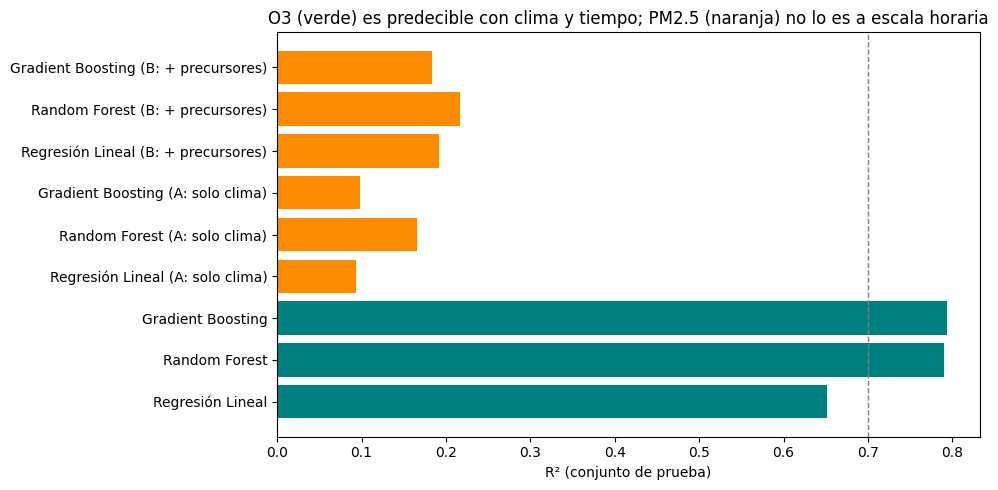

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["teal" if o == "O3" else "darkorange" for o in final["Objetivo"]]
ax.barh(final.index, final["r2"], color=colors)
ax.axvline(0.7, color="gray", ls="--", lw=1)
ax.set_xlabel("R² (conjunto de prueba)")
ax.set_title("O3 (verde) es predecible con clima y tiempo; PM2.5 (naranja) no lo es a escala horaria")
plt.tight_layout(); plt.show()

## 9. Conclusiones

### ¿La contaminación por O3 o PM2.5 está ligada al tráfico vehicular?

**Sí, pero de manera distinta para cada contaminante.**

- **O3 — vínculo indirecto y desfasado:** el ozono no sale del escape de los autos; se forma cuando la radiación solar hace reaccionar los precursores que el tráfico emite (NOx, CO, compuestos orgánicos). La evidencia está en el perfil horario: los NOx y el CO alcanzan su máximo a las 7–8 h (hora pico vehicular) y el O3 alcanza el suyo a las 13–15 h, tras horas de reacción fotoquímica. La correlación horaria O3–NOx es incluso *negativa* (−0.32), lo que refuerza que la relación es química y retardada, no simultánea.
- **PM2.5 — vínculo parcial:** correlaciona positivamente con los gases de combustión (NO2: +0.30, CO: +0.22) y agregar estos precursores mejoró el modelo, así que una fracción del PM2.5 sí proviene del tráfico. Pero la relación es débil y su perfil horario es casi plano: el tráfico es **una fuente entre varias** (industria, polvo, quemas), no la dominante.

### ¿Tendría efecto implantar un esquema de verificación vehicular?

**Sí, con impacto esperado principalmente sobre el O3 y parcial sobre el PM2.5.** Una flota mejor afinada emite menos NOx, CO e hidrocarburos, que son la materia prima del ozono fotoquímico; reducir precursores reduce el techo de O3 que el sol puede producir en días calurosos y despejados. Para el PM2.5 el efecto sería positivo pero limitado, porque nuestros datos indican que la combustión vehicular explica solo una parte de las partículas finas; un programa integral debería complementarse con control de emisiones industriales, pavimentación y control de quemas. Además, la verificación por sí sola no cambia las condiciones meteorológicas (inversiones térmicas, estancamiento) que disparan las contingencias: reduce la "materia prima", no el mecanismo.

### Con el pronóstico del clima de la mañana, ¿puedes predecir una contingencia ambiental?

**Para O3: sí, con confianza razonable.** Nuestro mejor modelo (Gradient Boosting con SR, RH, TOUT, WSR, Hour, Month) alcanza R² ≈ 0.79 y RMSE ≈ 7.6 ppb usando *únicamente* variables disponibles en un pronóstico meteorológico. Un día pronosticado con alta radiación solar, temperatura > 30 °C, humedad baja y viento moderado es un candidato claro a niveles altos de ozono, y el margen de error (~7.6 ppb) es pequeño frente al umbral de 120 ppb.

**Para PM2.5: no a escala horaria.** Con clima solamente el R² es ≈ 0.17 en el mejor caso: el pronóstico matutino no basta. Para este contaminante se requeriría (a) agregar los datos a escala **diaria**, (b) incluir variables de persistencia (el PM2.5 del día anterior) y (c) idealmente indicadores de inversión térmica.

### ¿Qué condiciones climáticas producen altos niveles de O3? ¿Y de PM2.5?

**Para O3 alto se necesita:**
1. **Radiación solar intensa** (r = +0.69) — el motor de la reacción; sin sol no hay ozono.
2. **Temperatura alta** (r = +0.53) — acelera la química; los peores días superan los 30 °C.
3. **Humedad relativa baja** (r = −0.66) — cielos despejados; con RH > 90 % casi nunca hay O3 alto.
4. Precursores disponibles del tráfico matutino y unas horas de espera: el pico llega a las 13–15 h.

**Para PM2.5 alto lo determinante no es el clima de esa hora, sino la incapacidad de la atmósfera para dispersar:**
1. **Viento débil** — sin ventilación las partículas se acumulan (mecanismo clave a escala de días, aunque su correlación horaria sea baja).
2. **Alta presión y aire estable** (r = −0.18) — condiciones anticiclónicas asociadas a inversiones térmicas que actúan como "tapa" sobre la ciudad.
3. **Ausencia de lluvia** — la lluvia lava las partículas del aire (RAINF casi siempre es 0 en Monterrey; por eso su correlación aparece baja).
4. **Acumulación vespertina/nocturna:** el ligero pico de PM2.5 a las 20–21 h coincide con el descenso de la capa de mezcla.

En síntesis: **el O3 es un contaminante "de días soleados y calurosos" y el PM2.5 uno "de días estancados"** — por eso el primero se predice bien con el pronóstico del clima y el segundo requiere modelar la dinámica de dispersión a escala diaria.

In [ ]:
spark.stop()